# Late Fusion of RGB, Joint, and Bone Streams for Violence Detection (RWF-2000)

In this notebook, we combine the predictions of three independently trained models
using late fusion to improve violence detection accuracy on the RWF-2000 dataset.

## What is done
- Load pre-trained RGB model (R3D-18) from checkpoint
- Load pre-trained Joint stream model (2s-AGCN) from checkpoint
- Load pre-trained Bone stream model (2s-AGCN) from checkpoint
- Run skeleton-based inference (joint and bone) using MMAction2's official test pipeline (10-clip TTA)
- Load precomputed RGB predictions aligned with the same validation order
- Fuse all three models' softmax probabilities using weighted averaging
- Evaluate fusion performance using accuracy and F1 score

## Models
| Model | Architecture | Individual Accuracy |
|-------|-------------|-------------------|
| RGB Stream | R3D-18 (3D ResNet) | 88.00% (old 83%) |
| Joint Stream | 2s-AGCN (joint features) | 80.75% |
| Bone Stream | 2s-AGCN (bone features) | 83.50% |

## Fusion Method
Late fusion — weighted average of softmax probabilities:
```
fused_score = w_rgb × P_rgb + w_joint × P_joint + w_bone × P_bone
prediction  = argmax(fused_score)
```

No retraining is required.

## Dataset

RWF-2000 validation set
400 videos (200 Fight, 200 NonFight)
Clean split with no overlap between training and validation data

## Checkpoints Used

RGB: checkpoints/rgb/r3d_epoch_16.pth
Joint: checkpoints/pose/2s-agcn-joint/best_acc_top1_epoch_8.pth
Bone: checkpoints/pose/2s-agcn-bone/best_acc_top1_epoch_13.pth

## Output

Best fusion result:
RGB 0.50 + Joint 0.20 + Bone 0.30 → 87.25% accuracy, F1: 0.878

## Imports and installations

In [1]:
# Mount Google Drive to access our saved files
from google.colab import drive
drive.mount('/content/drive')

# Install mmcv from saved wheel (fast, avoids 40min compilation)
!pip install /content/drive/MyDrive/mmcv-2.1.0-cp312-cp312-linux_x86_64.whl -q
!pip install mmengine -q

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.7/452.7 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 26.2 MB/s eta 0:00:00


In [2]:
# Clone MMAction2 repository and install it
# We disable the multimodal module since we don't need it
# and it causes import errors with newer transformers
%cd /content
!git clone https://github.com/open-mmlab/mmaction2.git -q
%cd /content/mmaction2
!pip install -e . -q
!sed -i 's/from .multimodal import \*/# from .multimodal import */' \
    /content/mmaction2/mmaction/models/__init__.py

/content
/content/mmaction2
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 70.3 MB/s eta 0:00:00


In [3]:
# PyTorch 2.10 changed how it loads checkpoints by default
# MMAction2 wasn't updated for this change, so we patch it manually
!sed -i 's/checkpoint = torch.load(filename, map_location=map_location)/checkpoint = torch.load(filename, map_location=map_location, weights_only=False)/' \
    /usr/local/lib/python3.12/dist-packages/mmengine/runner/checkpoint.py
print("Patched!")

Patched!


In [ ]:
# After installing new libraries, Python needs a fresh start
# to recognize them properly
import os
os.kill(os.getpid(), 9)

In [1]:
      # Load all required libraries
import torch
import torch.nn as nn
import numpy as np
import pickle
import os
from glob import glob
from torch.utils.data import Dataset, DataLoader
from torchvision.models.video import r3d_18
from decord import VideoReader, cpu
import torchvision.transforms as T
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from google.colab import drive
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


## Load RGB Predictions

In [2]:
# NEW result

RGB_PROBS_PATH  = '/content/drive/MyDrive/violence-detection/checkpoints/rgb_v2/rgb_v2_val_probs.npy'
RGB_LABELS_PATH = '/content/drive/MyDrive/violence-detection/checkpoints/rgb_v2/rgb_v2_val_labels.npy'

rgb_probs_arr = np.load(RGB_PROBS_PATH)
rgb_labels_arr = np.load(RGB_LABELS_PATH)

print("RGB probs shape:", rgb_probs_arr.shape)
print("RGB accuracy:", accuracy_score(rgb_labels_arr, np.argmax(rgb_probs_arr, axis=1)))

RGB probs shape: (400, 2)
RGB accuracy: 0.88


## Load Joint Predictions

In [3]:
JOINT_PATH = '/content/drive/MyDrive/violence-detection/checkpoints/pose/2s-agcn-joint/joint_val_predictions.pkl'

with open(JOINT_PATH, 'rb') as f:
    joint_preds = pickle.load(f)

joint_probs = np.array([p['pred_score'].numpy() for p in joint_preds])
joint_labels = np.array([p['gt_label'].item() for p in joint_preds])

print("Joint shape:", joint_probs.shape)
print("Joint accuracy:", accuracy_score(joint_labels, np.argmax(joint_probs, axis=1)))

Joint shape: (400, 2)
Joint accuracy: 0.8075


# Load Bone Predictions

In [4]:
BONE_PATH = '/content/drive/MyDrive/violence-detection/checkpoints/pose/2s-agcn-bone/bone_val_predictions.pkl'

with open(BONE_PATH, 'rb') as f:
    bone_preds = pickle.load(f)

bone_probs = np.array([p['pred_score'].numpy() for p in bone_preds])
bone_labels = np.array([p['gt_label'].item() for p in bone_preds])

print("Bone shape:", bone_probs.shape)
print("Bone accuracy:", accuracy_score(bone_labels, np.argmax(bone_probs, axis=1)))

Bone shape: (400, 2)
Bone accuracy: 0.835


## Check Alignment

In [5]:
print("RGB vs Joint labels match:", np.all(rgb_labels_arr == joint_labels))
print("Joint vs Bone labels match:", np.all(joint_labels == bone_labels))

assert np.all(rgb_labels_arr == joint_labels), "RGB and Joint order mismatch!"
assert np.all(joint_labels == bone_labels), "Joint and Bone order mismatch!"

labels = joint_labels
print("All streams aligned ✅")

RGB vs Joint labels match: True
Joint vs Bone labels match: True
All streams aligned ✅


## 3-stream fusion

In [6]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

print("=" * 70)
print(f"{'Weights (RGB / Joint / Bone)':<40} {'Acc':>10} {'F1':>10}")
print("=" * 70)

best_acc = -1
best_f1 = -1
best_preds = None
best_weights = None
best_fused = None
results = []

step = 0.05
weights_range = np.arange(0.0, 1.01, step)

for w_rgb in weights_range:
    for w_joint in weights_range:
        w_bone = round(1.0 - w_rgb - w_joint, 2)

        if w_bone < 0 or w_bone > 1:
            continue

        fused = (
            w_rgb * rgb_probs_arr +
            w_joint * joint_probs +
            w_bone * bone_probs
        )

        preds = np.argmax(fused, axis=1)
        acc = accuracy_score(labels, preds)
        f1 = f1_score(labels, preds)

        results.append((w_rgb, w_joint, w_bone, acc, f1))

        print(f"{w_rgb:.2f} / {w_joint:.2f} / {w_bone:.2f}{'':<20} {acc:>10.4f} {f1:>10.4f}")

        if acc > best_acc or (acc == best_acc and f1 > best_f1):
            best_acc = acc
            best_f1 = f1
            best_preds = preds
            best_weights = (w_rgb, w_joint, w_bone)
            best_fused = fused

print("=" * 70)
print(f"Best accuracy: {best_acc:.4f}")
print(f"Best F1      : {best_f1:.4f}")
print(f"Best weights : RGB {best_weights[0]:.2f}, Joint {best_weights[1]:.2f}, Bone {best_weights[2]:.2f}")

Weights (RGB / Joint / Bone)                    Acc         F1
0.00 / 0.00 / 1.00                         0.8350     0.8272
0.00 / 0.05 / 0.95                         0.8350     0.8272
0.00 / 0.10 / 0.90                         0.8325     0.8241
0.00 / 0.15 / 0.85                         0.8375     0.8294
0.00 / 0.20 / 0.80                         0.8350     0.8272
0.00 / 0.25 / 0.75                         0.8375     0.8303
0.00 / 0.30 / 0.70                         0.8350     0.8281
0.00 / 0.35 / 0.65                         0.8425     0.8364
0.00 / 0.40 / 0.60                         0.8375     0.8303
0.00 / 0.45 / 0.55                         0.8375     0.8312
0.00 / 0.50 / 0.50                         0.8400     0.8351
0.00 / 0.55 / 0.45                         0.8325     0.8269
0.00 / 0.60 / 0.40                         0.8375     0.8338
0.00 / 0.65 / 0.35                         0.8300     0.8283
0.00 / 0.70 / 0.30                         0.8250     0.8250
0.00 / 0.75 / 0.25    

## Analysis

In [7]:
print("\n=== RGB + Joint + Bone (Best Fusion) ===")
print(classification_report(labels, best_preds, target_names=['NonFight', 'Fight']))


=== RGB + Joint + Bone (Best Fusion) ===
              precision    recall  f1-score   support

    NonFight       0.89      0.90      0.89       200
       Fight       0.89      0.89      0.89       200

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



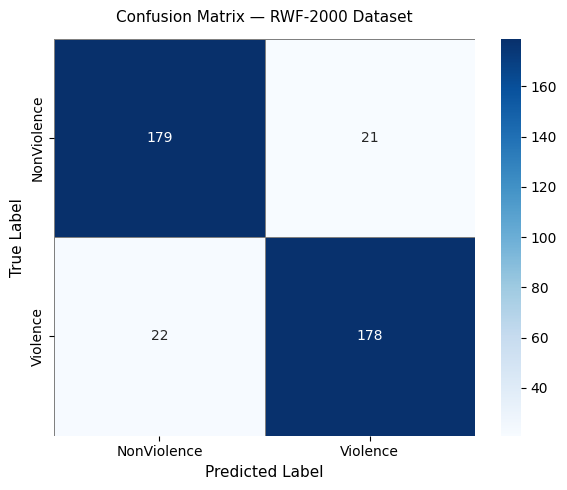

Saved confusion matrix to Drive.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, best_preds)

# Create figure
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NonViolence', 'Violence'],
    yticklabels=['NonViolence', 'Violence'],
    linewidths=0.5,
    linecolor='gray'
)

plt.title(
    'Confusion Matrix — RWF-2000 Dataset',
    fontsize=11,
    pad=12
)

plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)

plt.tight_layout()

# Save high-quality image
plt.savefig(
    '/content/drive/MyDrive/violence-detection/results/confusion_matrix_rwf2000.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved confusion matrix to Drive.")

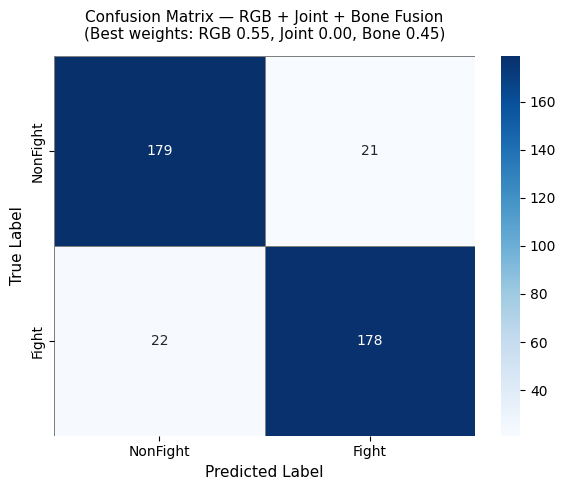

Saved to Drive.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(labels, best_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NonFight', 'Fight'],
    yticklabels=['NonFight', 'Fight'],
    linewidths=0.5,
    linecolor='gray'
)

plt.title('Confusion Matrix — RGB + Joint + Bone Fusion\n(Best weights: RGB 0.55, Joint 0.00, Bone 0.45)',
          fontsize=11, pad=12)
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/violence-detection/results/confusion_matrix_fusion.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Drive.")

In [10]:
rgb_acc = accuracy_score(labels, np.argmax(rgb_probs_arr, axis=1))
joint_acc = accuracy_score(labels, np.argmax(joint_probs, axis=1))
bone_acc = accuracy_score(labels, np.argmax(bone_probs, axis=1))

print("\n===== FINAL SUMMARY =====")
print(f"RGB only acc   : {rgb_acc:.4f}")
print(f"Joint only acc : {joint_acc:.4f}")
print(f"Bone only acc  : {bone_acc:.4f}")
print(f"Best fusion acc: {best_acc:.4f}")
print(f"Best fusion f1 : {best_f1:.4f}")
print(f"Best weights   : RGB {best_weights[0]:.2f} + Joint {best_weights[1]:.2f} + Bone {best_weights[2]:.2f}")


===== FINAL SUMMARY =====
RGB only acc   : 0.8800
Joint only acc : 0.8075
Bone only acc  : 0.8350
Best fusion acc: 0.8925
Best fusion f1 : 0.8922
Best weights   : RGB 0.45 + Joint 0.25 + Bone 0.30


## Save Results

In [11]:
save_path = '/content/drive/MyDrive/violence-detection/checkpoints/final_rgb_joint_bone_fusion_new.pkl'

results = {
    'labels': labels,
    'rgb_probs': rgb_probs_arr,
    'joint_probs': joint_probs,
    'bone_probs': bone_probs,
    'best_preds': best_preds,
    'best_weights': best_weights,
    'best_acc': best_acc,
    'best_f1': best_f1
}

with open(save_path, 'wb') as f:
    pickle.dump(results, f)

print("Final fusion results saved:", save_path)

Final fusion results saved: /content/drive/MyDrive/violence-detection/checkpoints/final_rgb_joint_bone_fusion_new.pkl
